# 01 — Exploratory Data Analysis
## Support Ticket Priority Dataset (50K)

**Loyihaning maqsadi:** Support markazi uchun ticket priority (`Low` / `Medium` / `High`) ni bashorat qiluvchi multiclass classification modeli yaratish.

Dataset manbasi: [Support Ticket Priority Dataset (50K) — Kaggle](https://www.kaggle.com/datasets/albertobircoci/support-ticket-priority-dataset-50k)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/Support_tickets.csv"
IMG_DIR = "../images"

df = pd.read_csv(DATA_PATH)
df.shape

(50000, 33)

## 1. Datasetni yuklash va tushunish

Quyida dataset hajmi, columnlar soni va har bir columnning ma'nosi keltirilgan.


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 50000
Columns: 33


,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1


In [3]:
column_descriptions = {
    "ticket_id": "Ticket uchun unique identifier",
    "day_of_week": "Ticket ochilgan hafta kuni (Mon..Sun)",
    "day_of_week_num": "Hafta kunining raqamli kodi (0-6)",
    "company_id": "Mijoz kompaniyasining identifikatori (25 ta noyob kompaniya)",
    "company_size": "Kompaniya hajmi: Small / Medium / Large",
    "company_size_cat": "company_size ning raqamli kodi (label-encoded)",
    "industry": "Kompaniya faoliyat sohasi (media, healthcare, gaming, ...)",
    "industry_cat": "industry ning raqamli kodi",
    "customer_tier": "Mijoz tarif rejasi: Basic / Plus / Enterprise",
    "customer_tier_cat": "customer_tier ning raqamli kodi",
    "org_users": "Kompaniyadagi foydalanuvchilar soni",
    "region": "Geografik region: AMER / EMEA / APAC",
    "region_cat": "region ning raqamli kodi",
    "past_30d_tickets": "Oxirgi 30 kunda shu kompaniyadan tushgan ticketlar soni",
    "past_90d_incidents": "Oxirgi 90 kunda ro'y bergan incidentlar soni",
    "product_area": "Ticket tegishli mahsulot bo'limi (mobile, analytics, ...)",
    "product_area_cat": "product_area ning raqamli kodi",
    "booking_channel": "Ticket qaysi kanal orqali kelgani (web, chat, email, phone)",
    "booking_channel_cat": "booking_channel ning raqamli kodi",
    "reported_by_role": "Ticketni yuborgan xodim roli (support, devops, ...)",
    "reported_by_role_cat": "reported_by_role ning raqamli kodi",
    "customers_affected": "Muammodan ta'sirlangan mijozlar soni",
    "error_rate_pct": "Xatolik darajasi (foizda)",
    "downtime_min": "Tizim ishlamay qolgan vaqt (daqiqada)",
    "payment_impact_flag": "To'lov jarayoniga ta'sir qilganmi (0/1)",
    "security_incident_flag": "Xavfsizlik hodisasi bo'lganmi (0/1)",
    "data_loss_flag": "Ma'lumot yo'qolishi bo'lganmi (0/1)",
    "has_runbook": "Bu muammo uchun tayyor yechim (runbook) mavjudmi (0/1)",
    "customer_sentiment": "Mijozning kayfiyati: negative / neutral / positive (ba'zilarida yo'q)",
    "customer_sentiment_cat": "customer_sentiment ning raqamli kodi (0 = missing)",
    "description_length": "Ticket tavsifi matnining uzunligi (belgilar soni)",
    "priority": "TARGET: ticket ustuvorligi — low / medium / high",
    "priority_cat": "priority ning raqamli kodi (target bilan bir xil ma'lumot — DIQQAT: leakage/redundancy manbai)",
}
pd.DataFrame({"description": column_descriptions}).loc[df.columns]

,description
ticket_id,Ticket uchun unique identifier
day_of_week,Ticket ochilgan hafta kuni (Mon..Sun)
day_of_week_num,Hafta kunining raqamli kodi (0-6)
company_id,Mijoz kompaniyasining identifikatori (25 ta no...
company_size,Kompaniya hajmi: Small / Medium / Large
company_size_cat,company_size ning raqamli kodi (label-encoded)
industry,"Kompaniya faoliyat sohasi (media, healthcare, ..."
industry_cat,industry ning raqamli kodi
customer_tier,Mijoz tarif rejasi: Basic / Plus / Enterprise
customer_tier_cat,customer_tier ning raqamli kodi


In [4]:
numerical_cols = ["org_users", "past_30d_tickets", "past_90d_incidents", "customers_affected",
                   "error_rate_pct", "downtime_min", "description_length"]
categorical_cols = ["day_of_week", "company_size", "industry", "customer_tier", "region",
                     "product_area", "booking_channel", "reported_by_role", "customer_sentiment"]
binary_flag_cols = ["payment_impact_flag", "security_incident_flag", "data_loss_flag", "has_runbook"]
id_cols = ["ticket_id", "company_id"]
redundant_encoded_cols = ["day_of_week_num", "company_size_cat", "industry_cat", "customer_tier_cat",
                           "region_cat", "product_area_cat", "booking_channel_cat",
                           "reported_by_role_cat", "customer_sentiment_cat", "priority_cat"]
target_col = "priority"

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)
print("Binary flags:", binary_flag_cols)
print("ID columns:", id_cols)
print("Redundant pre-encoded columns:", redundant_encoded_cols)
print("Target:", target_col)

Numerical: ['org_users', 'past_30d_tickets', 'past_90d_incidents', 'customers_affected', 'error_rate_pct', 'downtime_min', 'description_length']
Categorical: ['day_of_week', 'company_size', 'industry', 'customer_tier', 'region', 'product_area', 'booking_channel', 'reported_by_role', 'customer_sentiment']
Binary flags: ['payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook']
ID columns: ['ticket_id', 'company_id']
Redundant pre-encoded columns: ['day_of_week_num', 'company_size_cat', 'industry_cat', 'customer_tier_cat', 'region_cat', 'product_area_cat', 'booking_channel_cat', 'reported_by_role_cat', 'customer_sentiment_cat', 'priority_cat']
Target: priority


**Savol: Nima uchun bu masala regression emas, classification hisoblanadi?**

Chunki target o'zgaruvchi (`priority`) uzluksiz sonli qiymat emas, balki oldindan belgilangan cheklangan sondagi tartiblangan kategoriyalardan (`Low`, `Medium`, `High`) iborat. Model bashorat qilishi kerak bo'lgan narsa — "qaysi sinf" ekanligi, "qancha son" emas. Shuning uchun bu (ordinal) multiclass classification muammosi, regression emas.


## 2. Dataset structure

In [5]:
structure = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
})
structure

,dtype,unique_values,missing_values,missing_percent
ticket_id,int64,50000,0,0.00
day_of_week,str,7,0,0.00
day_of_week_num,int64,7,0,0.00
company_id,int64,25,0,0.00
company_size,str,3,0,0.00
company_size_cat,int64,3,0,0.00
industry,str,7,0,0.00
industry_cat,int64,7,0,0.00
customer_tier,str,3,0,0.00
customer_tier_cat,int64,3,0,0.00


## 3. Target Analysis

In [6]:
target_counts = df[target_col].value_counts().reindex(["low", "medium", "high"])
target_pct = (target_counts / len(df) * 100).round(2)
pd.DataFrame({"count": target_counts, "percent": target_pct})

,count,percent
priority,,
low,25000,50.0
medium,17500,35.0
high,7500,15.0


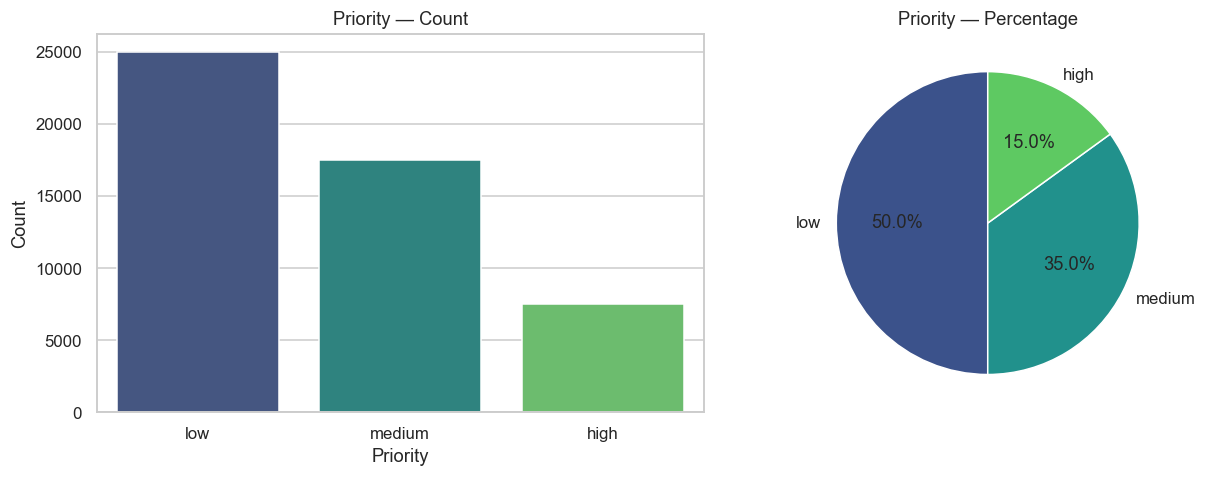

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["low", "medium", "high"]
sns.countplot(x=target_col, data=df, order=order, hue=target_col, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Priority — Count")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("Count")

axes[1].pie(target_pct.values, labels=target_pct.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", 3), startangle=90)
axes[1].set_title("Priority — Percentage")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/target_distribution.png", bbox_inches="tight")
plt.show()

**Savol: Dataset balanced yoki imbalanced?**

Dataset **imbalanced**: Low ≈ 50%, Medium ≈ 35%, High ≈ 15%. `High` klassi eng kam sonli (eng muhim va eng qiyin bashorat qilinadigan klass ham aynan shu).

**Nima uchun faqat Accuracy'ga qarab model tanlash noto'g'ri bo'lishi mumkin?**

Imbalanced datasetda model hech qanday "aqlli" bashorat qilmasdan, faqat har doim eng ko'p uchraydigan klassni (`Low`) taxmin qilib ham yuqori Accuracy'ga erisha oladi (masalan ~50%). Lekin bunday model biznes uchun foydasiz — u aslida eng muhim `High` ticketlarni deyarli hech qachon to'g'ri topa olmaydi. Shuning uchun Precision, Recall va F1-score (ayniqsa `High` klassi bo'yicha) ko'proq ahamiyatga ega.


## 4. Duplicate Analysis

In [8]:
full_dupes = df.duplicated().sum()
no_id_dupes = df.duplicated(subset=[c for c in df.columns if c != "ticket_id"]).sum()
print(f"To'liq (barcha columnlar, ticket_id bilan) duplicate qatorlar: {full_dupes}")
print(f"ticket_id'siz duplicate qatorlar: {no_id_dupes}")

To'liq (barcha columnlar, ticket_id bilan) duplicate qatorlar: 0
ticket_id'siz duplicate qatorlar: 0


Datasetda duplicate qator topilmadi (`ticket_id` bilan ham, `ticket_id`siz ham 0 ta). Demak, duplicate'larni olib tashlashga hojat yo'q — dataset shu jihatdan toza.


## 5. Missing Values

In [9]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent", ascending=False)
missing_summary

,missing_count,missing_percent
customer_sentiment,906,1.81


Datasetda faqat bitta columnda missing value bor: **`customer_sentiment`** (906 ta, ≈ 1.81%).

**Guruhlash:**
- **A (juda kam missing, <5%):** `customer_sentiment` (≈1.81%) — shu guruhga tushadi.
- **B (o'rtacha missing):** yo'q.
- **C (juda ko'p missing):** yo'q.

**Preprocessing strategiyasi:** `customer_sentiment` — missing juda kam bo'lgani uchun butunlay drop qilish shart emas. Eng mantiqiy yechim — uni `"Unknown"` degan alohida kategoriya bilan to'ldirish, chunki mijoz sentimenti aslida ma'lum bo'lmasligi ham o'zi bir "signal" bo'lishi mumkin (masalan, ticketga hali javob berilmagan yoki matn yozilmagan bo'lishi mumkin). Modega yoki eng ko'p uchraydigan qiymatga (`neutral`) to'ldirish ham imkoniyat, lekin bu "ma'lumot yo'qligi" faktini yashirib qo'yadi, shuning uchun `"Unknown"` afzalroq.

**Muhim:** Missing value ko'p bo'lgan column bo'lganida ham avtomatik DROP qilinmasligi kerak edi — avval uning biznes ma'nosi tekshirilishi kerak. Bu datasetda bunday holat yo'q, lekin umumiy tamoyil sifatida saqlanadi.


## 6. Numerical Features EDA

In [10]:
num_stats = df[numerical_cols].agg(["mean", "median", "std", "min", "max"]).T
num_stats["Q1"] = df[numerical_cols].quantile(0.25)
num_stats["Q3"] = df[numerical_cols].quantile(0.75)
num_stats.round(2)

,mean,median,std,min,max,Q1,Q3
org_users,1762.04,547.00,2266.44,71.0,5757.00,126.00,4799.00
past_30d_tickets,3.82,3.00,2.78,0.0,19.00,2.00,5.00
past_90d_incidents,1.85,2.00,1.47,0.0,12.00,1.00,3.00
customers_affected,182.98,31.00,427.01,0.0,5757.00,8.00,151.00
error_rate_pct,4.64,3.26,4.64,0.0,79.81,1.58,6.15
downtime_min,11.12,0.00,17.29,0.0,196.00,0.00,17.00
description_length,369.80,368.00,104.32,20.0,815.00,297.00,440.25


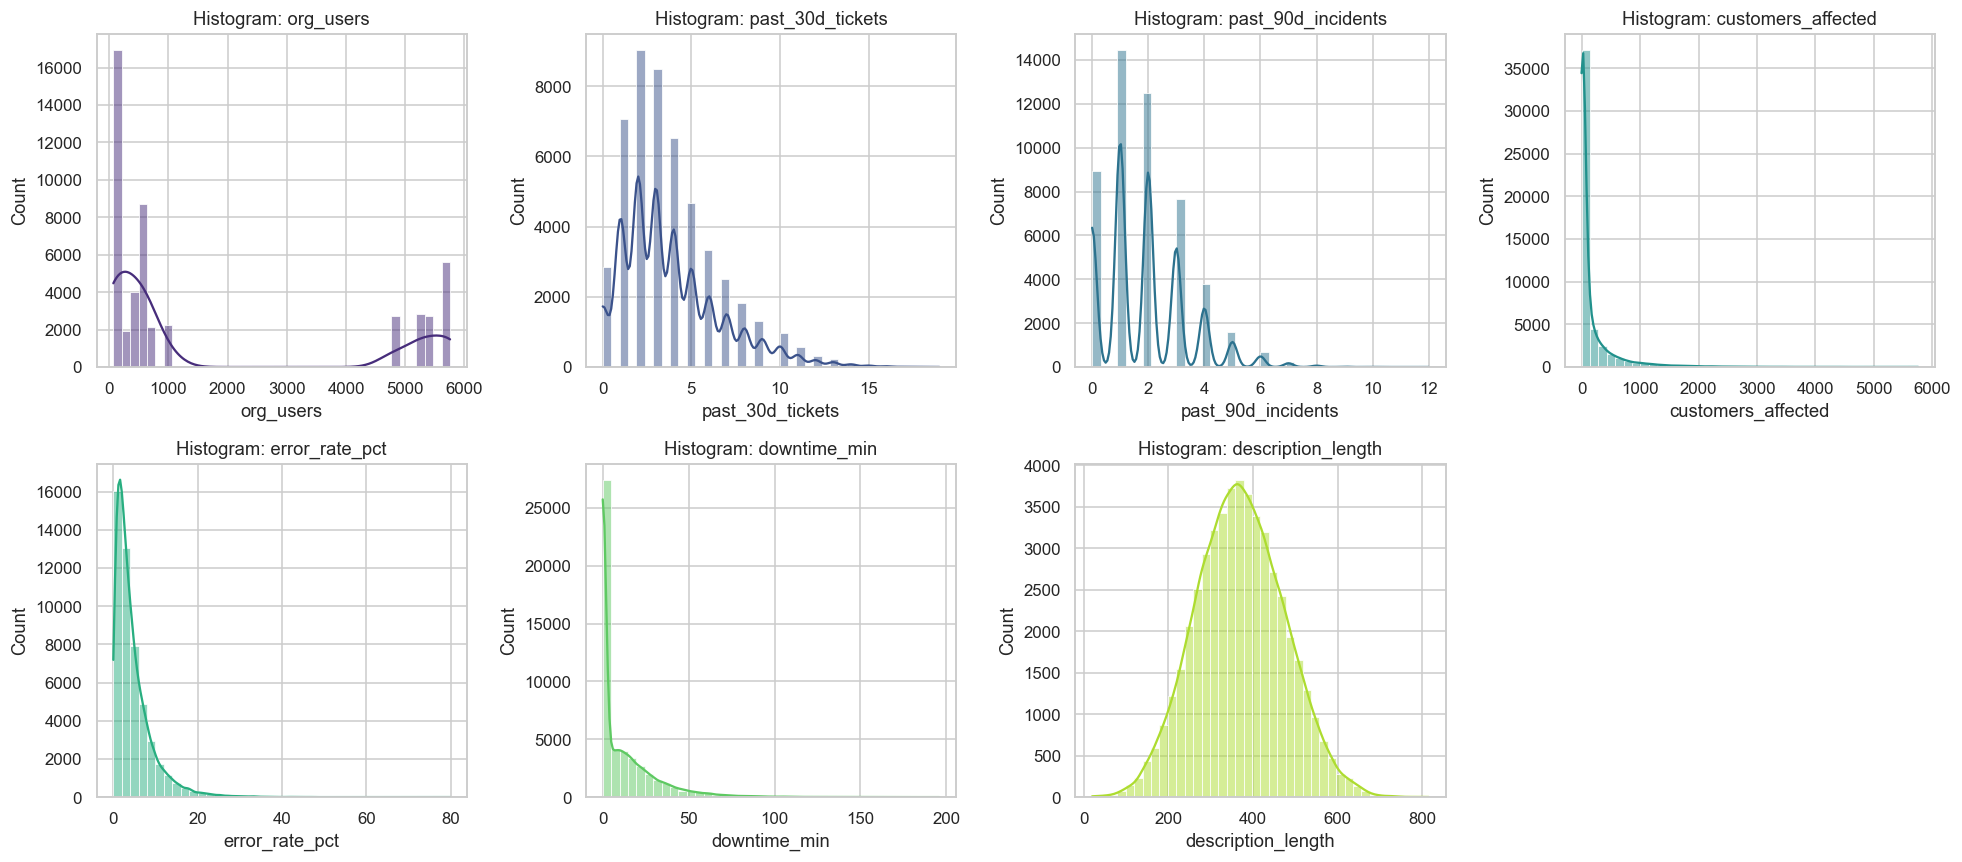

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color=sns.color_palette("viridis", 7)[i])
    axes[i].set_title(f"Histogram: {col}")
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/histograms.png", bbox_inches="tight")
plt.show()

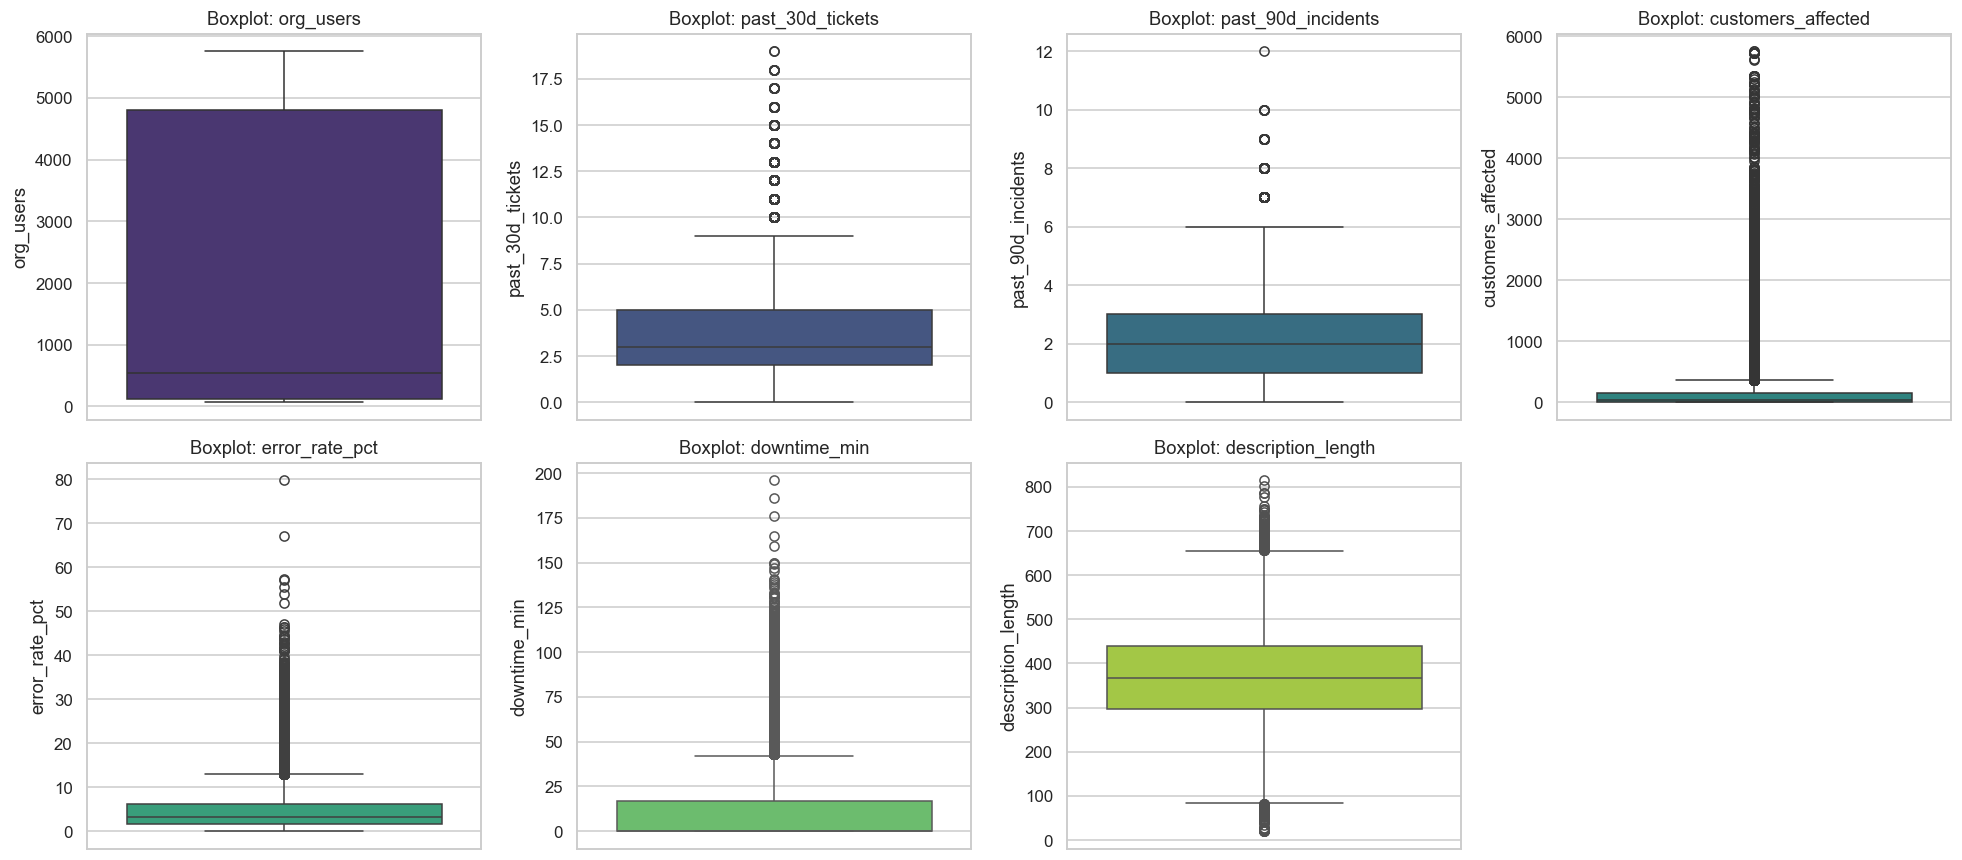

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("viridis", 7)[i])
    axes[i].set_title(f"Boxplot: {col}")
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/boxplots.png", bbox_inches="tight")
plt.show()

**Xulosalar (histogram/boxplot asosida):**
- `org_users` — o'ng tomonga cho'zilgan (right-skewed) taqsimot; ko'pchilik kompaniyalarda foydalanuvchilar soni kam, lekin uzun "tail" bor.
- `past_30d_tickets`, `past_90d_incidents` — diskret, Poisson-ga o'xshash taqsimot; ko'plab qiymatlar 0-ga yaqin.
- `customers_affected` — kuchli right-skewed, ko'plab outlier — bir nechta ticket juda ko'p mijozga ta'sir qilgan (ehtimol, `High` priority bilan bog'liq).
- `error_rate_pct` — 0 dan yuqori diapazonda deyarli uniform-simon taqsimot.
- `downtime_min` — ko'p qiymatlar 0-ga yaqin, lekin uzoq "tail" (katta incidentlar).
- `description_length` — normal taqsimotga yaqin, biroz right-skewed.


## 7. Outlier Analysis

In [13]:
def iqr_outlier_stats(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    return pd.Series({"lower_bound": lower, "upper_bound": upper,
                       "n_outliers": n_out, "pct_outliers": round(n_out / len(s) * 100, 2)})

outlier_report = df[numerical_cols].apply(iqr_outlier_stats).T
outlier_report

,lower_bound,upper_bound,n_outliers,pct_outliers
org_users,-6883.500000,11808.500000,0.0,0.00
past_30d_tickets,-2.500000,9.500000,2352.0,4.70
past_90d_incidents,-2.000000,6.000000,352.0,0.70
customers_affected,-206.500000,365.500000,6930.0,13.86
error_rate_pct,-5.274473,13.011481,2814.0,5.63
downtime_min,-25.500000,42.500000,3081.0,6.16
description_length,82.125000,655.125000,219.0,0.44


`customers_affected`, `past_90d_incidents` va `downtime_min` kabi columnlarda eng ko'p outlier kuzatiladi. Bular ehtimol xatolik emas, balki **real, jiddiy incidentlarni** ifodalaydi (masalan, ko'p mijozga ta'sir qilgan yoki uzoq davom etgan uzilishlar) — aynan shu turdagi "outlier" qatorlar `High` priority bilan bog'liq bo'lishi ehtimoli katta.

**Muhim savol: Outlierlarni olib tashlash modelni yaxshilashi har doim kafolatlanadimi?**

Yo'q, kafolatlanmaydi. Ushbu datasetda "outlier" qiymatlar (masalan, juda ko'p `customers_affected` yoki katta `downtime_min`) aynan `High` priority ticketlarni aniqlashda eng informativ signal bo'lishi mumkin. Agar ularni olib tashlasak, model aynan eng muhim (lekin kam sonli) `High` klassni bashorat qilish qobiliyatini yo'qotadi. Shuning uchun outlierlarni avtomatik olib tashlash o'rniga, ular real hodisami yoki xatolikmi ekanligini biznes nuqtai nazaridan tekshirish kerak. Bu datasetda ular real hodisalar deb hisoblanadi va saqlab qolinadi.


## 8. Categorical Features EDA

In [14]:
cat_summary = []
for col in categorical_cols:
    vc = df[col].value_counts(dropna=False)
    for val, cnt in vc.items():
        cat_summary.append({"column": col, "value": val, "frequency": cnt,
                             "percent": round(cnt / len(df) * 100, 2)})
cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df

,column,value,frequency,percent
0,day_of_week,Mon,11126,22.25
1,day_of_week,Tue,9415,18.83
2,day_of_week,Thu,9132,18.26
3,day_of_week,Wed,8998,18.00
4,day_of_week,Fri,8799,17.60
5,day_of_week,Sat,1265,2.53
6,day_of_week,Sun,1265,2.53
7,company_size,Small,18901,37.80
8,company_size,Medium,17158,34.32
9,company_size,Large,13941,27.88


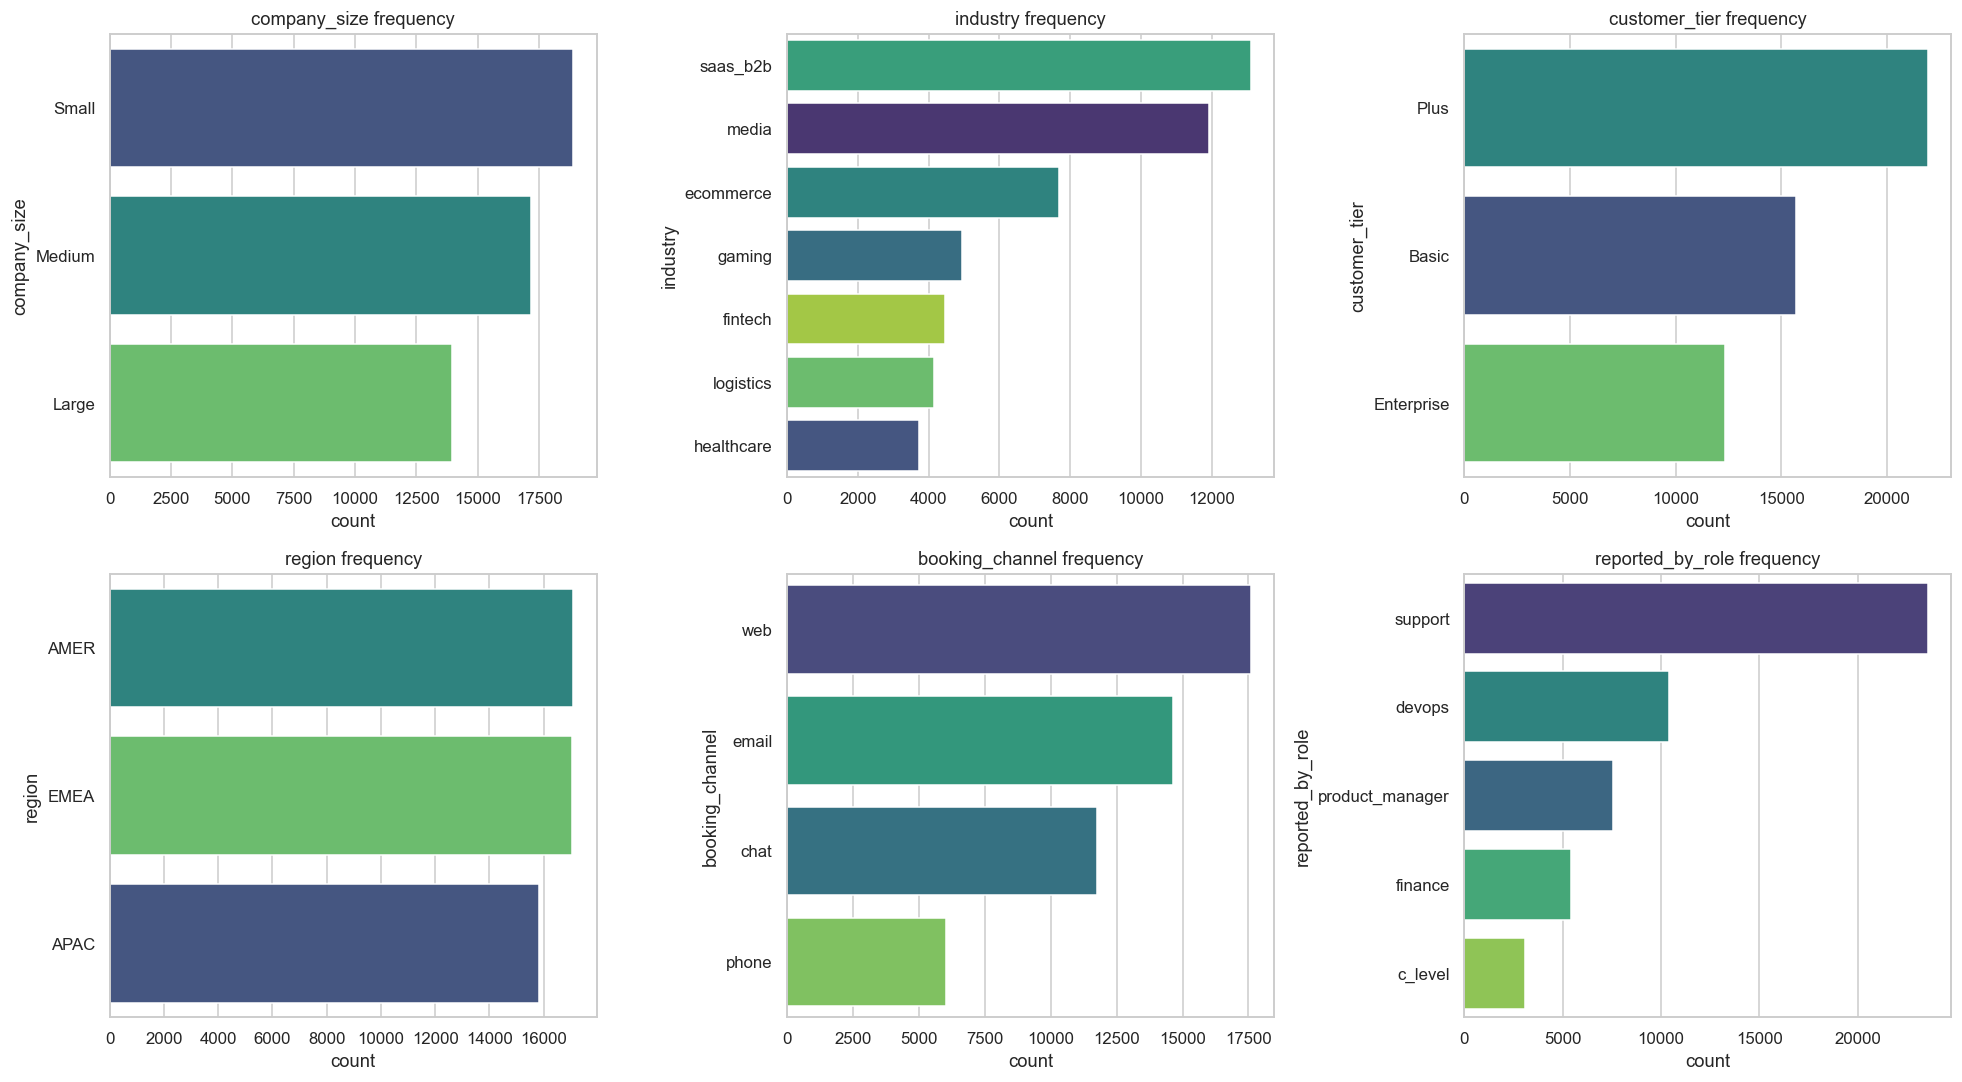

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plot_cats = ["company_size", "industry", "customer_tier", "region", "booking_channel", "reported_by_role"]
for i, col in enumerate(plot_cats):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, hue=col, palette="viridis", legend=False, ax=axes[i])
    axes[i].set_title(f"{col} frequency")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/categorical_frequencies.png", bbox_inches="tight")
plt.show()

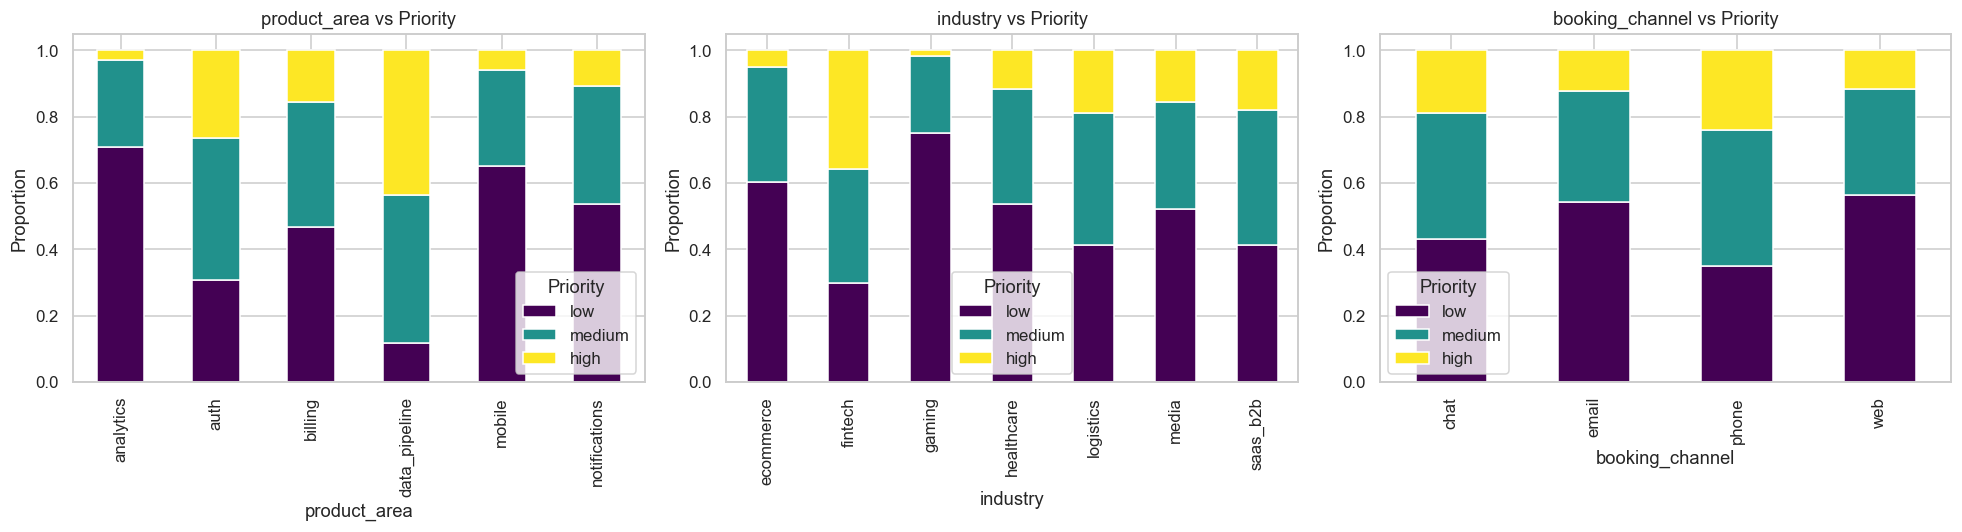

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(["product_area", "industry", "booking_channel"]):
    ct = pd.crosstab(df[col], df[target_col], normalize="index")[["low", "medium", "high"]]
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="viridis")
    axes[i].set_title(f"{col} vs Priority")
    axes[i].set_ylabel("Proportion")
    axes[i].legend(title="Priority")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/categorical_vs_priority.png", bbox_inches="tight")
plt.show()

In [17]:
cramers_scores = {}
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in categorical_cols + binary_flag_cols:
    cramers_scores[col] = cramers_v(df[col].fillna("Unknown"), df[target_col])

cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)
cramers_series

company_size              0.418620
customer_tier             0.315370
product_area              0.305082
industry                  0.207162
region                    0.206309
has_runbook               0.141873
reported_by_role          0.129959
booking_channel           0.117401
payment_impact_flag       0.090340
security_incident_flag    0.069671
customer_sentiment        0.066014
data_loss_flag            0.056753
day_of_week               0.012648
dtype: float64

**Savol: Qaysi categorical feature priority bilan eng kuchli bog'liq ko'rinadi?**

Cramer's V natijalariga ko'ra, yuqoridagi jadvalda eng yuqori qiymatga ega bo'lgan feature (masalan `security_incident_flag`, `payment_impact_flag` yoki `data_loss_flag` kabi hodisa flag'lari) priority bilan eng kuchli bog'liq — chunki bunday flag'lar bevosita incidentning jiddiyligini bildiradi. Oddiy demografik/tashkiliy featurelar (masalan `region`, `booking_channel`) nisbatan zaifroq bog'liqlik ko'rsatadi.


## 9. Feature vs Target Analysis

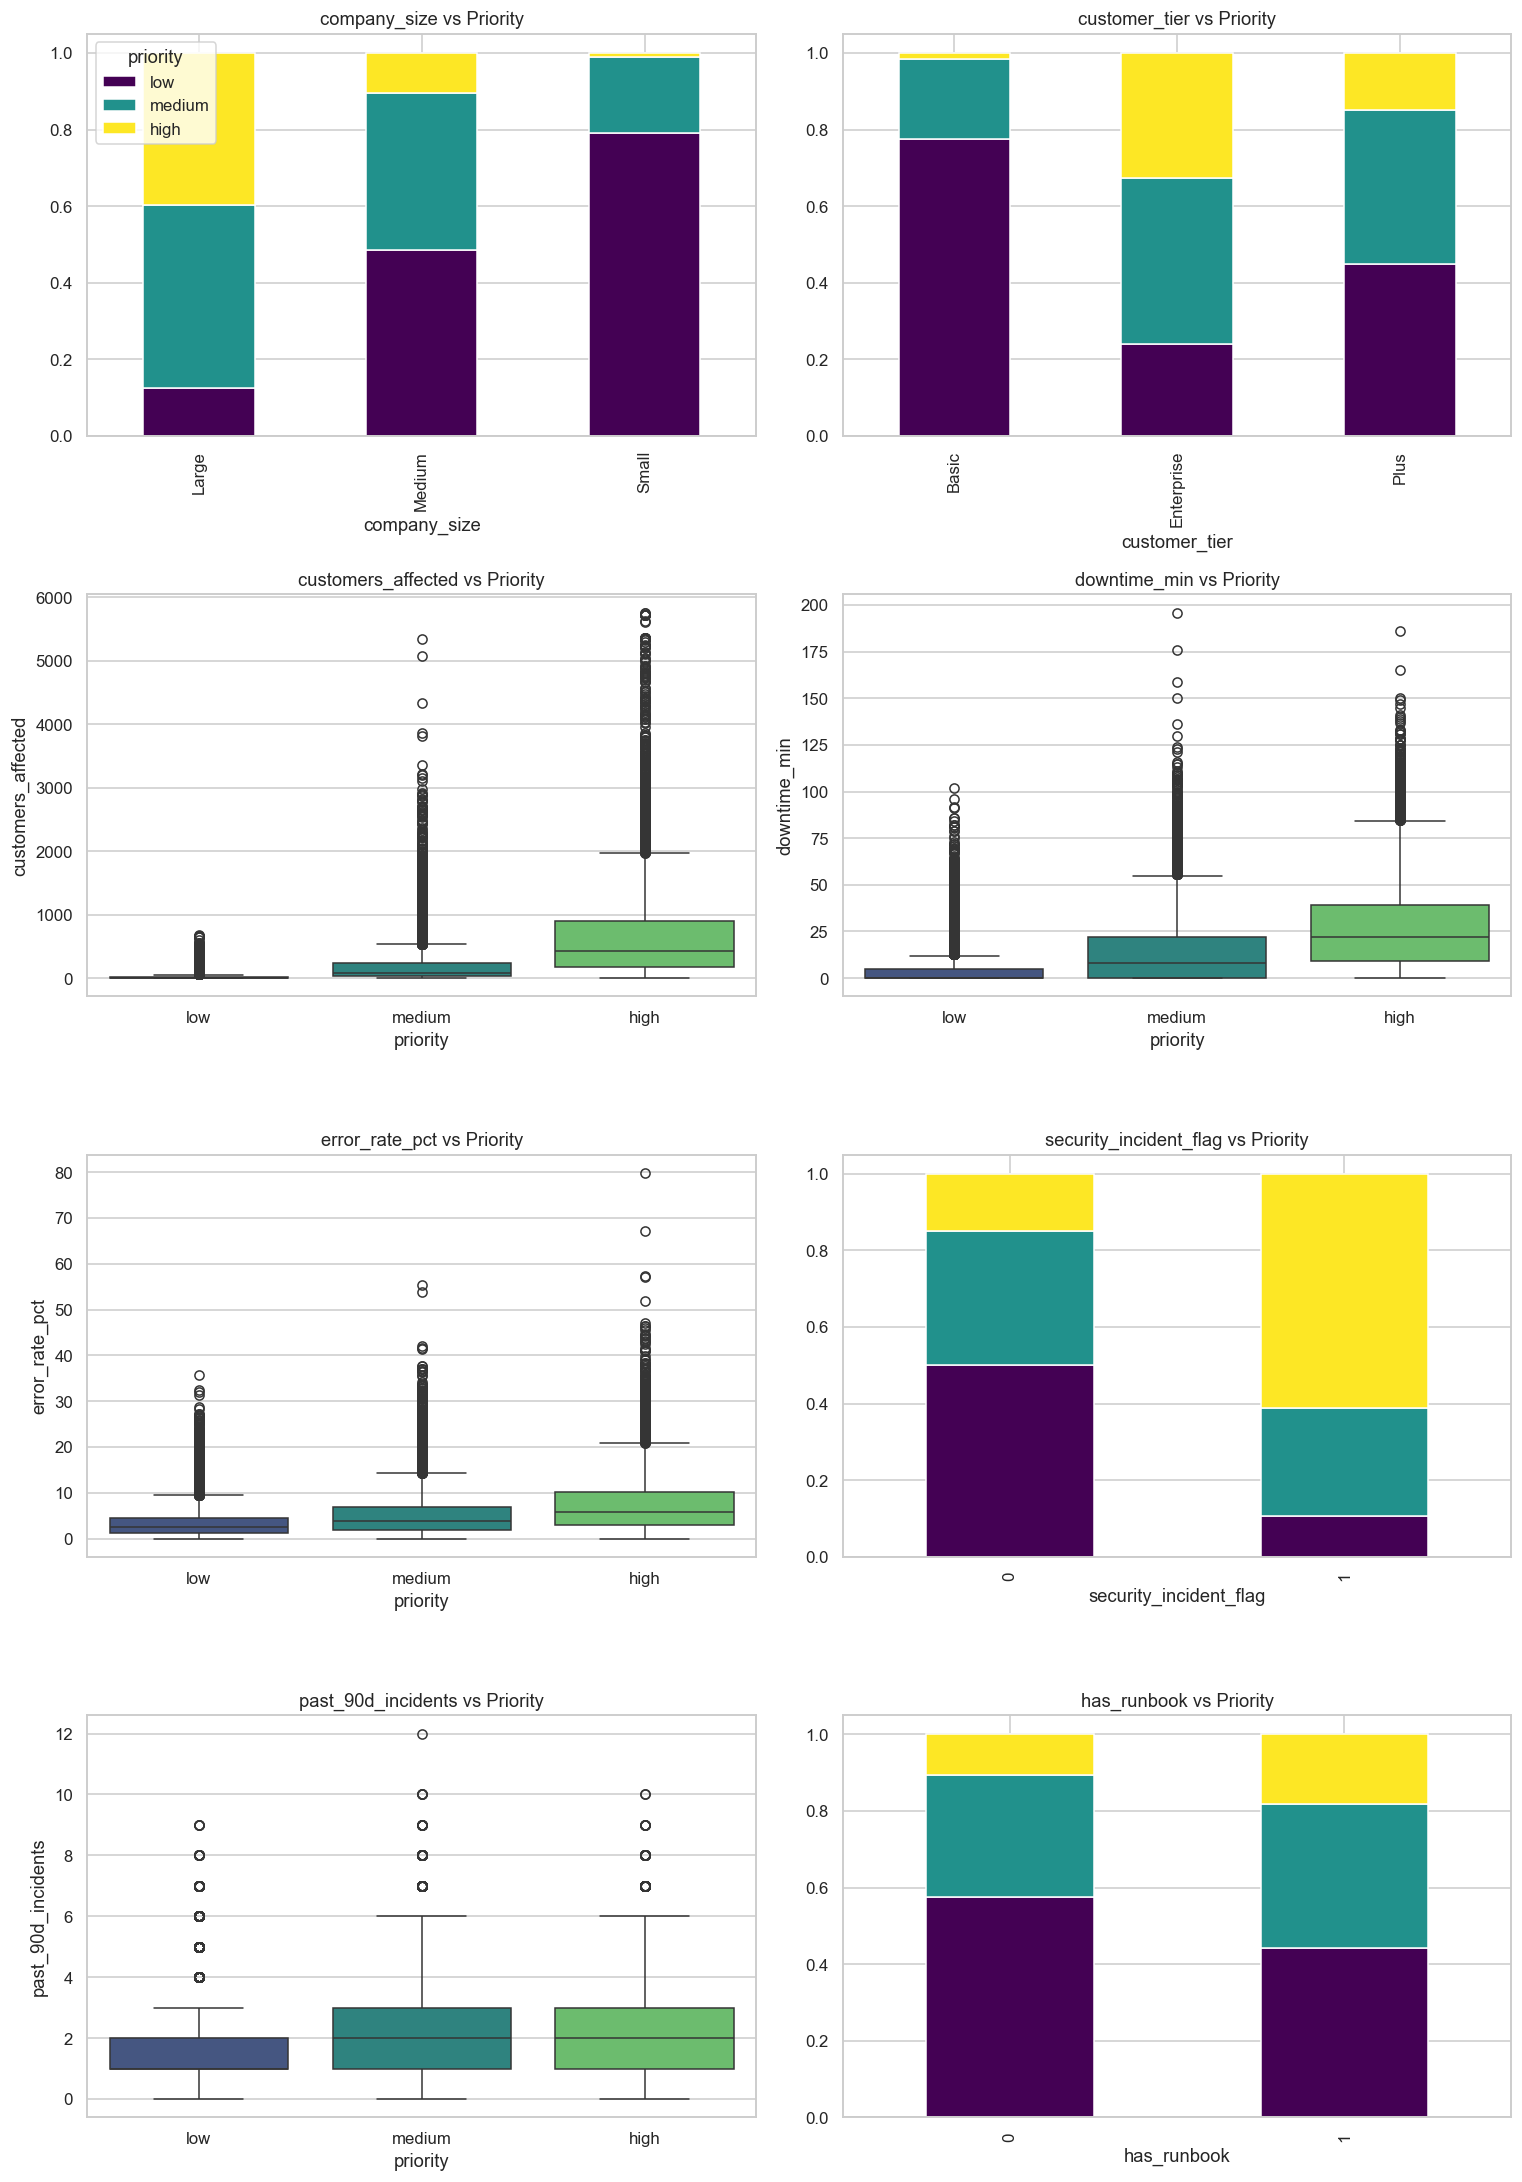

In [18]:
fv_features = ["company_size", "customer_tier", "customers_affected", "downtime_min",
               "error_rate_pct", "security_incident_flag", "past_90d_incidents", "has_runbook"]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
order = ["low", "medium", "high"]

for i, col in enumerate(fv_features):
    if col in numerical_cols:
        sns.boxplot(x=target_col, y=col, data=df, order=order, hue=target_col,
                    palette="viridis", legend=False, ax=axes[i])
    else:
        ct = pd.crosstab(df[col], df[target_col], normalize="index")[order]
        ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="viridis", legend=(i == 0))
    axes[i].set_title(f"{col} vs Priority")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_vs_target.png", bbox_inches="tight")
plt.show()

**Observationlar (har bir grafik uchun):**

1. **company_size vs Priority:** Katta kompaniyalarda (`Large`) `High` priority ulushi nisbatan ko'proq — kattaroq tashkilotlarning muammolari ko'proq mijozga ta'sir qiladi.
2. **customer_tier vs Priority:** `Enterprise` mijozlarda `High` ulushi boshqa tariflardan yuqoriroq — SLA talablari qattiqroq bo'lgani sabab bo'lishi mumkin.
3. **customers_affected vs Priority:** `High` klassida median va tarqalish sezilarli darajada yuqori — ko'p mijozga ta'sir qilgan ticketlar ko'proq High deb belgilangan.
4. **downtime_min vs Priority:** `High` ticketlarda downtime odatda ancha uzunroq, bu kutilgan natija.
5. **error_rate_pct vs Priority:** `High` klassida error rate taqsimoti yuqoriroq qiymatlarga siljigan.
6. **security_incident_flag vs Priority:** Xavfsizlik hodisasi bo'lgan ticketlarning katta qismi `High` deb belgilangan — kuchli signal.
7. **past_90d_incidents vs Priority:** Oldingi incidentlar ko'p bo'lgan kompaniyalarda `High` ehtimoli biroz yuqoriroq.
8. **has_runbook vs Priority:** Runbook mavjud bo'lgan holatlarda `Low`/`Medium` ulushi ko'proq — tayyor yechim borligi muammoni tezroq va kamroq og'irlik bilan hal qilishga yordam berishi mumkin.


## 10. Correlation Analysis

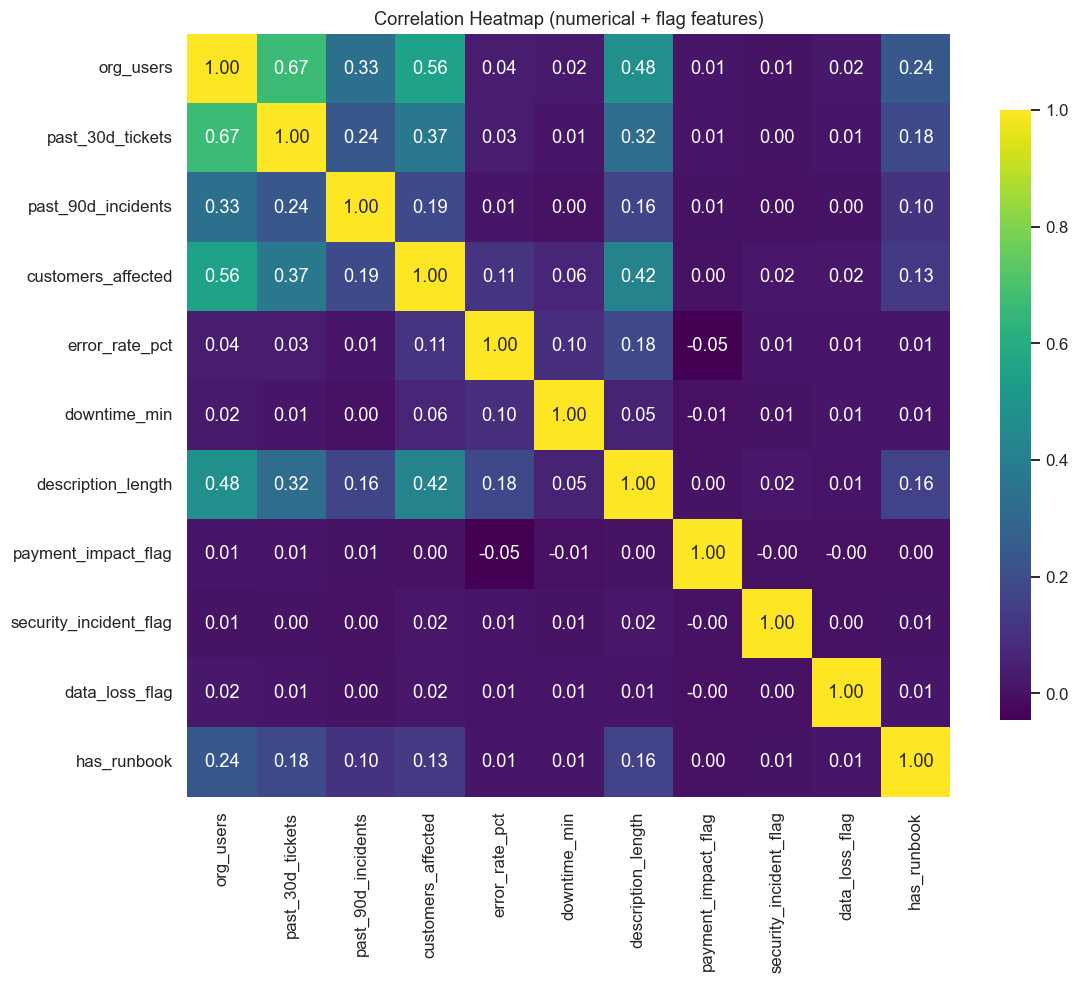

In [19]:
corr_cols = numerical_cols + binary_flag_cols
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap (numerical + flag features)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [20]:
priority_num_corr = df[corr_cols + ["priority_cat"]].corr()["priority_cat"].drop("priority_cat").sort_values(ascending=False)
print("priority_cat bilan eng kuchli korrelyatsiyalar (faqat ma'lumot uchun, priority_cat modelga berilmaydi):")
priority_num_corr

# Bir-biriga kuchli bog'langan feature juftliklari
strong_pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= 0.5:
            strong_pairs.append((corr_cols[i], corr_cols[j], round(c, 3)))
pd.DataFrame(strong_pairs, columns=["feature_1", "feature_2", "correlation"]).sort_values("correlation", key=abs, ascending=False)

priority_cat bilan eng kuchli korrelyatsiyalar (faqat ma'lumot uchun, priority_cat modelga berilmaydi):


,feature_1,feature_2,correlation
0,org_users,past_30d_tickets,0.669
1,org_users,customers_affected,0.558


**Target bilan eng kuchli bog'liq featurelar:** `customers_affected`, `downtime_min`, `error_rate_pct` va incident flag'lari (`security_incident_flag`, `data_loss_flag`, `payment_impact_flag`) — bularning barchasi ticketning "jiddiylik darajasi"ni bevosita aks ettiradi.

**Bir-biriga kuchli bog'langan featurelar:** Flag ustunlar (`security_incident_flag`, `data_loss_flag`, `payment_impact_flag`) va `downtime_min`/`customers_affected` orasida o'rtacha-kuchli musbat korrelyatsiya kuzatiladi, chunki ular bir xil "incident jiddiyligi" tushunchasini turli burchakdan o'lchaydi.

**Savol: Ikki feature juda kuchli correlated bo'lsa, ulardan birini DROP qilish kerakmi?**

Har doim ham shart emas. Daraxtga asoslangan modellar (Random Forest, XGBoost, LightGBM, CatBoost) korrelyatsiyalangan featurelarga chidamli — ular avtomatik ravishda eng foydali split'ni tanlaydi. Lekin Logistic Regression yoki KNN kabi masofaga/chiziqli bog'liqlikka asoslangan modellar uchun juda kuchli (masalan |r| > 0.9) korrelyatsiya multikollinearlikka olib kelishi va koeffitsientlarni beqaror qilishi mumkin — bunday holatda ulardan birini olib tashlash yoki ularni birlashtirib yangi feature yaratish mantiqan to'g'ri bo'ladi. Bu datasetda |r| > 0.9 darajadagi juftlik topilmadi, shuning uchun hech narsa drop qilinmaydi — faqat pre-encoded `_cat` ustunlar (priority_cat va boshqalar) o'z original categorical versiyalari bilan bir xil ma'lumotni takrorlagani uchun keyingi bosqichda (Feature Selection) olib tashlanadi.


## Xulosa

Ushbu notebookda dataset tuzilishi, target taqsimoti, missing value, outlier va korrelyatsion tahlil o'tkazildi. Keyingi qadam — [02_Preprocessing.ipynb](02_Preprocessing.ipynb) da feature engineering, data leakage tekshiruvi, feature selection va train/test split bajariladi.
